In [6]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert, butter, filtfilt, windows
import os

# 导入你修改后的 MVDNet
from 论文复现.model import MVDNet
from 论文复现.main import *

In [7]:
# ==========================================
# 1. 专业信号处理：共振解调与包络谱
# ==========================================
def bandpass_filter(signal, fs=64000, low=2000, high=20000):
    nyq = 0.5 * fs
    b, a = butter(4, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)

def get_envelope_spectrum(signal, fs=64000):
    # 第一步：带通滤波 (提取高频共振带)
    f_sig = bandpass_filter(signal, fs)
    # 第二步：希尔伯特包络
    env = np.abs(hilbert(f_sig))
    env -= np.mean(env) # 去直流
    # 第三步：FFT
    n = len(env)
    freqs = np.fft.fftfreq(n, 1/fs)
    p = np.abs(np.fft.fft(env)) / n
    return freqs[freqs > 0], p[freqs > 0]

# ==========================================
# 2. 模型推理逻辑：使用模型内置的 Mask 接口
# ==========================================
def separate_long_signal(model, raw_sig, device):
    model.eval()
    chunk_size = model.input_len # 直接使用模型定义的长度
    num_chunks = len(raw_sig) // chunk_size
    sep_list = [[] for _ in range(model.K)]

    with torch.no_grad():
        for i in range(num_chunks):
            chunk = raw_sig[i*chunk_size : (i+1)*chunk_size]
            
            # 局部 Z-score 归一化 (必须与训练一致)
            norm_chunk = (chunk - np.mean(chunk)) / (np.std(chunk) + 1e-8)
            x = torch.tensor(norm_chunk, dtype=torch.float32).view(1, 1, -1).to(device)
            
            # 【修改点】调用模型内置的 Mask 分离函数
            # 该函数返回的是一个列表，包含 K 个 (1, 1, L) 的 Tensor
            separated_chunks = model.get_mask_separation(x)
            
            for k in range(model.K):
                # 转回 numpy 并打平
                s_k = separated_chunks[k].cpu().numpy().flatten()
                sep_list[k].append(s_k)
                
    # 拼接所有时间段
    return [np.concatenate(s) for s in sep_list]

# ==========================================
# 3. 绘图主程序（对标论文图 5）
# ==========================================
def plot_final_separation(data_root,save_name):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 【修改点】初始化模型，input_len 需与训练一致
    model = MVDNet(K=2, input_len=2048).to(device)
    
    # 加载训练好的权重
    model_path = "论文复现/mvd_net_final.pth"
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device))
        print(f"成功加载模型权重: {model_path}")
    else:
        print("警告: 未找到权重文件，将使用随机初始化模型进行测试。")

    # 读取 Task A 真实的复合故障样本 (LA2+LA3: 滚子+外圈)
    target_folder = os.path.join(data_root, 'M0_G0_LA2+LA3_RA0', 'Sample_7')
    
    # 查找符合条件的 CSV 文件
    try:
        file = [f for f in os.listdir(target_folder) if "20Hz_-10kN" in f and "leftaxlebox" in f][0]
        df = pd.read_csv(os.path.join(target_folder, file))
    except (IndexError, FileNotFoundError):
        print(f"错误: 在 {target_folder} 下未找到匹配的 CSV 文件。")
        return

    # 取约 1 秒数据 (2048 的倍数) 以获得极致频率分辨率
    # 63488 = 2048 * 31
    raw_signal = df['CH17'].values[:63488] 
    
    # 执行模型分离
    separated_signals = separate_long_signal(model, raw_signal, device)
    # 绘图布局：2x2
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fs = 64000
    
    # Task A 的特征：K=0 通常对应第一个单故障 (Roller), K=1 对应第二个 (Outer Race)
    # 这取决于你训练时 Label 0 和 1 的定义
    titles = ["Separated Component 1 (Roller BF?)", "Separated Component 2 (Outer Race OR?)"]
    fcf_list = [9.7, 23.4] # BJTU 数据集 20Hz 下的理论特征频率

    for k in range(2):
        sig_k = separated_signals[k]
        t = np.arange(len(sig_k)) / fs
        
        # 第一行：时域波形 (截取前 0.5s 显示)
        axes[0, k].plot(t[:32000], sig_k[:32000], color='tab:blue', lw=0.5)
        axes[0, k].set_title(f"{titles[k]} - Time Domain")
        axes[0, k].set_xlabel("Time (s)")
        axes[0, k].set_ylabel("Amplitude")
        axes[0, k].grid(True, alpha=0.3)

        # 第二行：包络谱分析
        f, p = get_envelope_spectrum(sig_k, fs)
        axes[1, k].plot(f, p, color='tab:red', lw=1.0)
        axes[1, k].set_xlim(0, 150) # 关注低频故障特征
        axes[1, k].set_title(f"{titles[k]} - Envelope Spectrum")
        axes[1, k].set_xlabel("Frequency (Hz)")
        axes[1, k].set_ylabel("Magnitude")
        
        # 标注理论特征频率线
        for freq in fcf_list:
            axes[1, k].axvline(freq, color='green', ls='--', alpha=0.4)
        
        # 重点标注当前通道应该寻找的目标频率
        target_f = fcf_list[k]
        axes[1, k].annotate(f'Target: {target_f}Hz', 
                            xy=(target_f, np.max(p)*0.7), 
                            color='darkgreen', weight='bold')
        axes[1, k].grid(True, alpha=0.3)

    plt.suptitle("MVD-Net Reproduction: Compound Fault Separation (Task A)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    save_dir = "separation_results"   # 想放的文件夹名称

    # 如果文件夹不存在 → 自动创建
    os.makedirs(save_dir, exist_ok=True)
    
    save_path = os.path.join(save_dir, f"reproduced_figure_5_v2_{save_name}.png")
    
    plt.savefig(save_path, dpi=300)
    
    print(f"图像已保存到: {save_path}")
    plt.show()



运行环境: cuda
Epoch [1/100] | Loss: 1.6009 | Rec: 1.5658 | KL: 0.3505
Epoch [2/100] | Loss: 1.5540 | Rec: 1.5463 | KL: 0.0764
Epoch [3/100] | Loss: 1.5490 | Rec: 1.5442 | KL: 0.0481
Epoch [4/100] | Loss: 1.5473 | Rec: 1.5387 | KL: 0.0857
Epoch [5/100] | Loss: 1.4718 | Rec: 1.4197 | KL: 0.5210
Epoch [6/100] | Loss: 1.3288 | Rec: 1.2322 | KL: 0.9663
Epoch [7/100] | Loss: 1.2151 | Rec: 1.0984 | KL: 1.1672
Epoch [8/100] | Loss: 1.0954 | Rec: 0.9605 | KL: 1.3486
Epoch [9/100] | Loss: 0.9702 | Rec: 0.8202 | KL: 1.5000
Epoch [10/100] | Loss: 0.8668 | Rec: 0.7076 | KL: 1.5921
Epoch [11/100] | Loss: 0.8059 | Rec: 0.6424 | KL: 1.6350
Epoch [12/100] | Loss: 0.7440 | Rec: 0.5769 | KL: 1.6717
Epoch [13/100] | Loss: 0.7025 | Rec: 0.5310 | KL: 1.7152
Epoch [14/100] | Loss: 0.6702 | Rec: 0.4951 | KL: 1.7517
Epoch [15/100] | Loss: 0.6514 | Rec: 0.4793 | KL: 1.7213
Epoch [16/100] | Loss: 0.6215 | Rec: 0.4469 | KL: 1.7462
Epoch [17/100] | Loss: 0.5931 | Rec: 0.4135 | KL: 1.7965
Epoch [18/100] | Loss: 0.5752

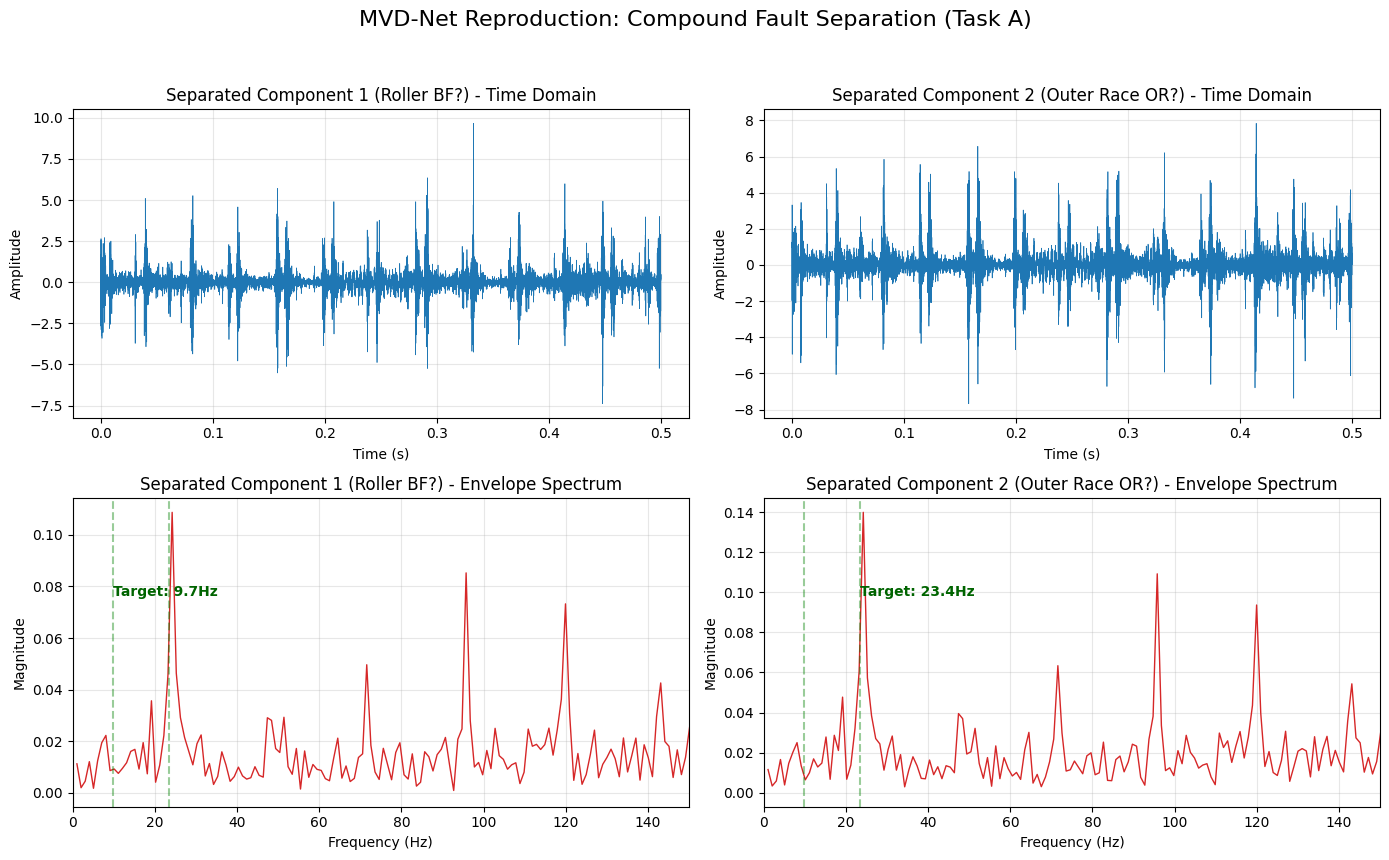

In [8]:
if __name__ == "__main__":
    # 请确保路径指向你的数据集根目录
    DATA_PATH = r"E:\BaiduNetdiskDownload\BJTU-RAO Bogie Datasets\Data\BJTU_RAO_Bogie_Datasets\BJTU_RAO_Bogie_Datasets"
    for i in range(1):
        run_training(DATA_PATH)
        plot_final_separation(DATA_PATH,save_name=i)